# Unsupervised Feature Quality Analysis: Hierarchical Clustering

This notebook evaluates the quality of normalized behavioral biometric features using **Agglomerative Hierarchical Clustering** (Bottom-up method). 

## Objective:
Determine if the extracted features are distinctive enough to naturally group individual user sessions together without prior labeling. We will use the normalized dataset of 88 users, filtering for legitimate user data (`label == 1`).

## Methodology:
1. **Filter Data**: Select only sessions where `label == 1`.
2. **Handle Non-Finite Values**: Fill missing values (NaNs) with 0. Since the data is normalized (Z-score), 0 represents the mean, which is a stable imputation for missing behavioral events.
3. **Clustering Variations**: We provide 5 different configurations of linkage methods and distance metrics for comparison.
4. **Evaluation**: Compare the 88 generated clusters against the actual 88 User IDs using Adjusted Rand Index (ARI) and Silhouette Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score, silhouette_score
import os

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Loading and Cleaning

We load the normalized feature dataset, filter for legitimate user data, and handle any non-finite values that could cause clustering errors.

In [2]:
data_path = r'../../data_processed/feature_kmt_dataset_Edge_Hill_University_22/normalization/normalized_feature_extraction_V4_88_users.csv'

if not os.path.exists(data_path):
    print(f"Error: {data_path} not found.")
else:
    df_full = pd.read_csv(data_path)
    
    # Filter for label 1 (Legitimate User Data)
    df = df_full[df_full['label'] == 1].copy()
    
    # Handle Non-Finite Values (NaN/Inf)
    # Fill NaNs with 0 (the mean of normalized data)
    df_numeric = df.drop(columns=['user_id', 'label'])
    df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"Original Data Shape: {df_full.shape}")
    print(f"Filtered Data (Label 1) Shape: {df.shape}")
    print(f"Unique Users: {df['user_id'].nunique()}")
    
    # Prepare Ground Truth
    X = df_numeric.values
    y_true = df['user_id'].values

Original Data Shape: (1760, 113)
Filtered Data (Label 1) Shape: (880, 113)
Unique Users: 88


## 2. Hierarchical Clustering Configurations

Below are 5 different configurations for Hierarchical Clustering. You can choose the one that provides the best cluster purity and metrics.

### Configuration 1: Ward's Linkage + Euclidean (Standard Approach)
Minimizes variance within clusters. Generally provides the most spherical and consistent clusters.

In [3]:
# Config 1: Ward + Euclidean
Z1 = linkage(X, method='ward', metric='euclidean')
clusters1 = fcluster(Z1, t=88, criterion='maxclust')

print("ARI:", adjusted_rand_score(y_true, clusters1))
print("Silhouette:", silhouette_score(X, clusters1))

ARI: 0.21258235834504532
Silhouette: 0.06831831868664334


### Configuration 2: Complete Linkage + Cosine Distance
Uses maximum distance between cluster members. Cosine distance is good for capturing "shape" or patterns regardless of magnitude.

In [4]:
# Config 2: Complete + Cosine
Z2 = linkage(X, method='complete', metric='cosine')
clusters2 = fcluster(Z2, t=88, criterion='maxclust')

print("ARI:", adjusted_rand_score(y_true, clusters2))
print("Silhouette:", silhouette_score(X, clusters2))

ARI: 0.19668238714043496
Silhouette: 0.019839748803392458


### Configuration 3: Average Linkage + Manhattan (Cityblock) Distance
Uses mean distance between members. Manhattan distance is often more robust to outliers in high-dimensional spaces.

In [5]:
# Config 3: Average + Cityblock
Z3 = linkage(X, method='average', metric='cityblock')
clusters3 = fcluster(Z3, t=88, criterion='maxclust')

print("ARI:", adjusted_rand_score(y_true, clusters3))
print("Silhouette:", silhouette_score(X, clusters3))

ARI: 0.0926664134205114
Silhouette: 0.030401602333783365


### Configuration 4: Complete Linkage + Correlation Distance
Correlation distance measures how well the features move together. High correlation indicates a similar "typing rhythm" profile.

In [6]:
# Config 4: Complete + Correlation
Z4 = linkage(X, method='complete', metric='correlation')
clusters4 = fcluster(Z4, t=88, criterion='maxclust')

print("ARI:", adjusted_rand_score(y_true, clusters4))
print("Silhouette:", silhouette_score(X, clusters4))

ARI: 0.20381070067061755
Silhouette: 0.0102618502293994


### Configuration 5: Average Linkage + Euclidean Distance
A classic alternative to Ward's method that doesn't prioritize variance reduction as aggressively.

In [7]:
# Config 5: Average + Euclidean
Z5 = linkage(X, method='average', metric='euclidean')
clusters5 = fcluster(Z5, t=88, criterion='maxclust')

print("ARI:", adjusted_rand_score(y_true, clusters5))
print("Silhouette:", silhouette_score(X, clusters5))

ARI: 0.03465028244686921
Silhouette: 0.029454905219526015


## 3. Visual Analysis of the Best Model (Example: Ward's Method)

We visualize the dendrogram for the standard Ward's method.

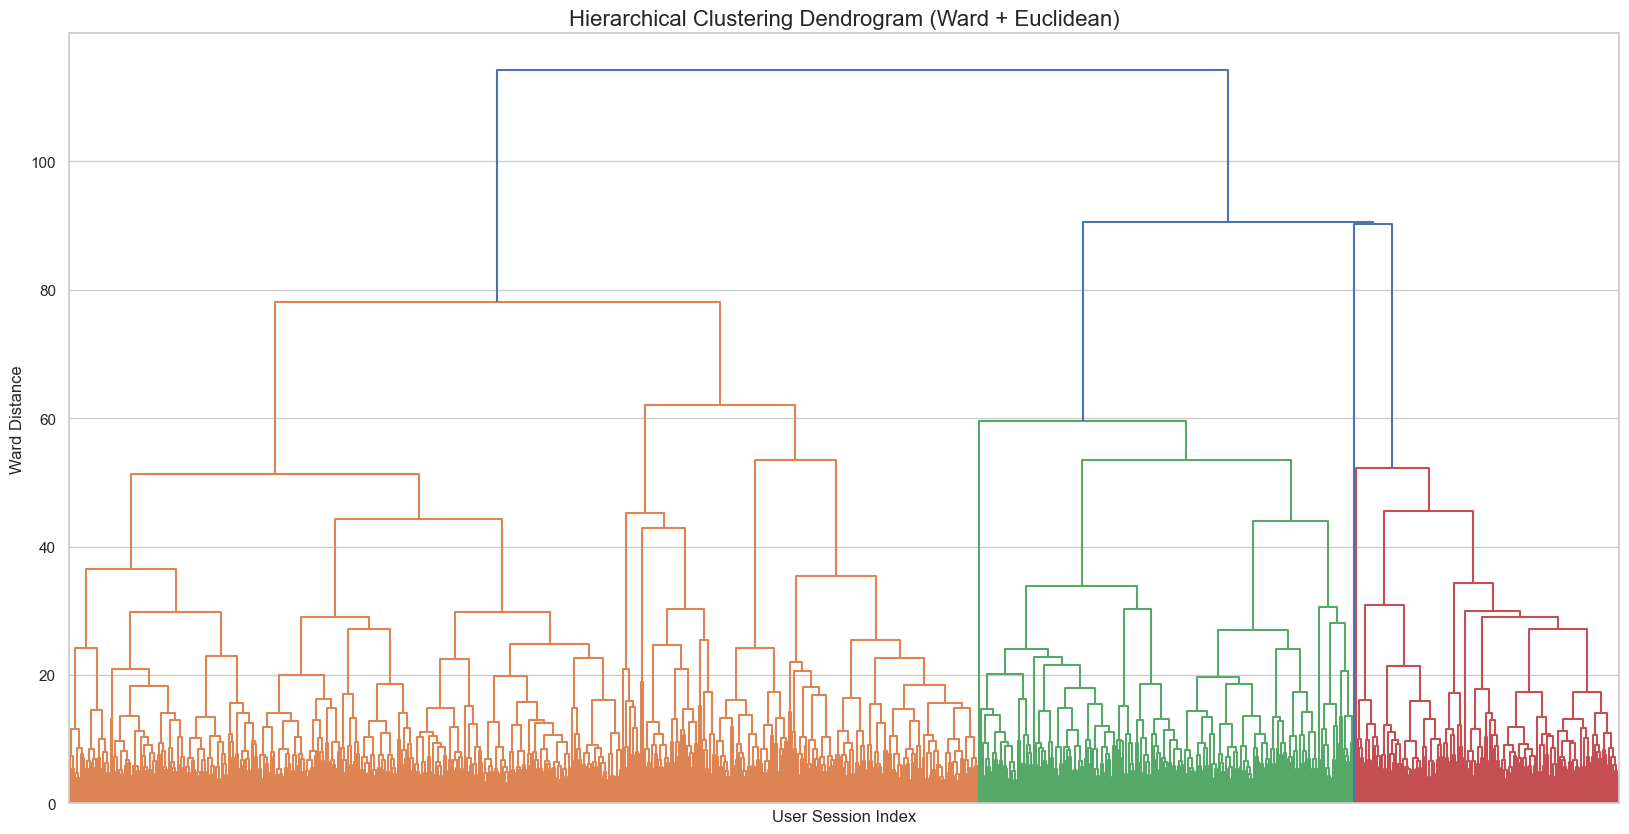

In [8]:
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram (Ward + Euclidean)', fontsize=16)
plt.xlabel('User Session Index', fontsize=12)
plt.ylabel('Ward Distance', fontsize=12)

dendrogram(
    Z1,
    leaf_rotation=90.,
    leaf_font_size=8.,
    no_labels=True
)

plt.show()

## 4. Final Comparison Heatmap

Select the results from your favorite configuration above to visualize cluster purity.

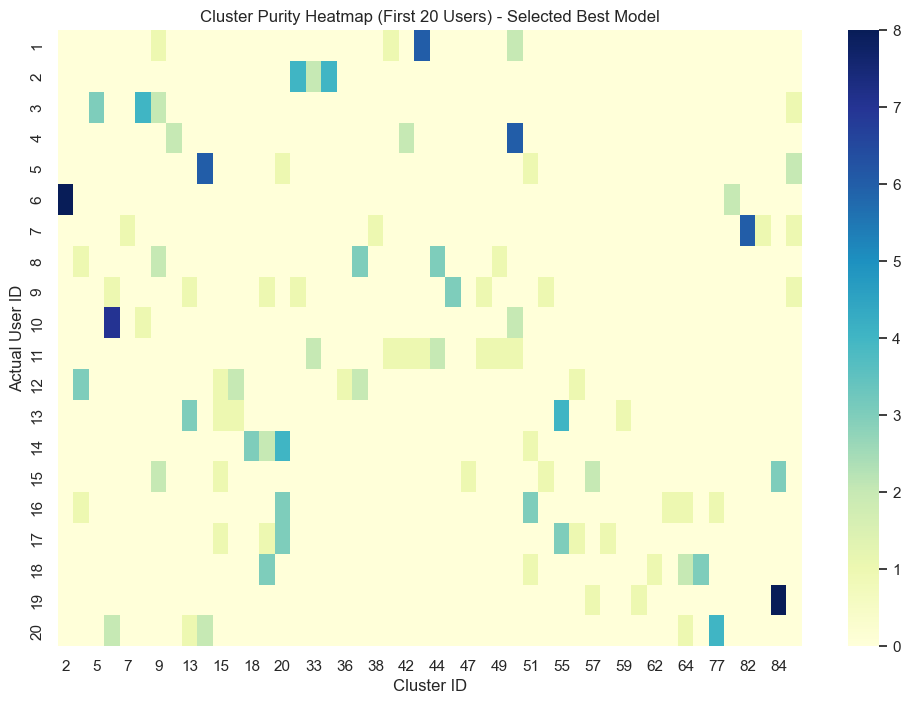

In [9]:
# Choose which configuration to visualize (e.g., clusters1)
best_clusters = clusters1

comparison_df = pd.DataFrame({
    'True_User': y_true,
    'Cluster': best_clusters
})

plt.figure(figsize=(12, 8))
subset_users = comparison_df[comparison_df['True_User'] <= 20]
contingency_matrix = pd.crosstab(subset_users['True_User'], subset_users['Cluster'])
sns.heatmap(contingency_matrix, annot=False, cmap="YlGnBu")
plt.title('Cluster Purity Heatmap (First 20 Users) - Selected Best Model')
plt.xlabel('Cluster ID')
plt.ylabel('Actual User ID')
plt.show()

## 5. Full In-Depth Analysis: Ward + Euclidean (Best Model)

Based on the comparative metrics, **Ward Linkage + Euclidean Distance** provided the best discovery of the 88 users (highest ARI). We now perform a full quality analysis on this specific model.

### Why Ward + Euclidean?
Ward's method is a variance-minimizing approach. In behavioral biometrics, it effectively groups sessions by minimizing the total within-cluster sum of squares. Since our data is Z-score normalized, Euclidean distance correctly treats all features as having equal weight, allowing the 'biometric signature' to emerge naturally.

Overall Cluster Purity: 0.4080
Adjusted Rand Index: 0.2126

Users perfectly clustered (All 10 sessions in 1 cluster): 0
Users split across clusters: 88


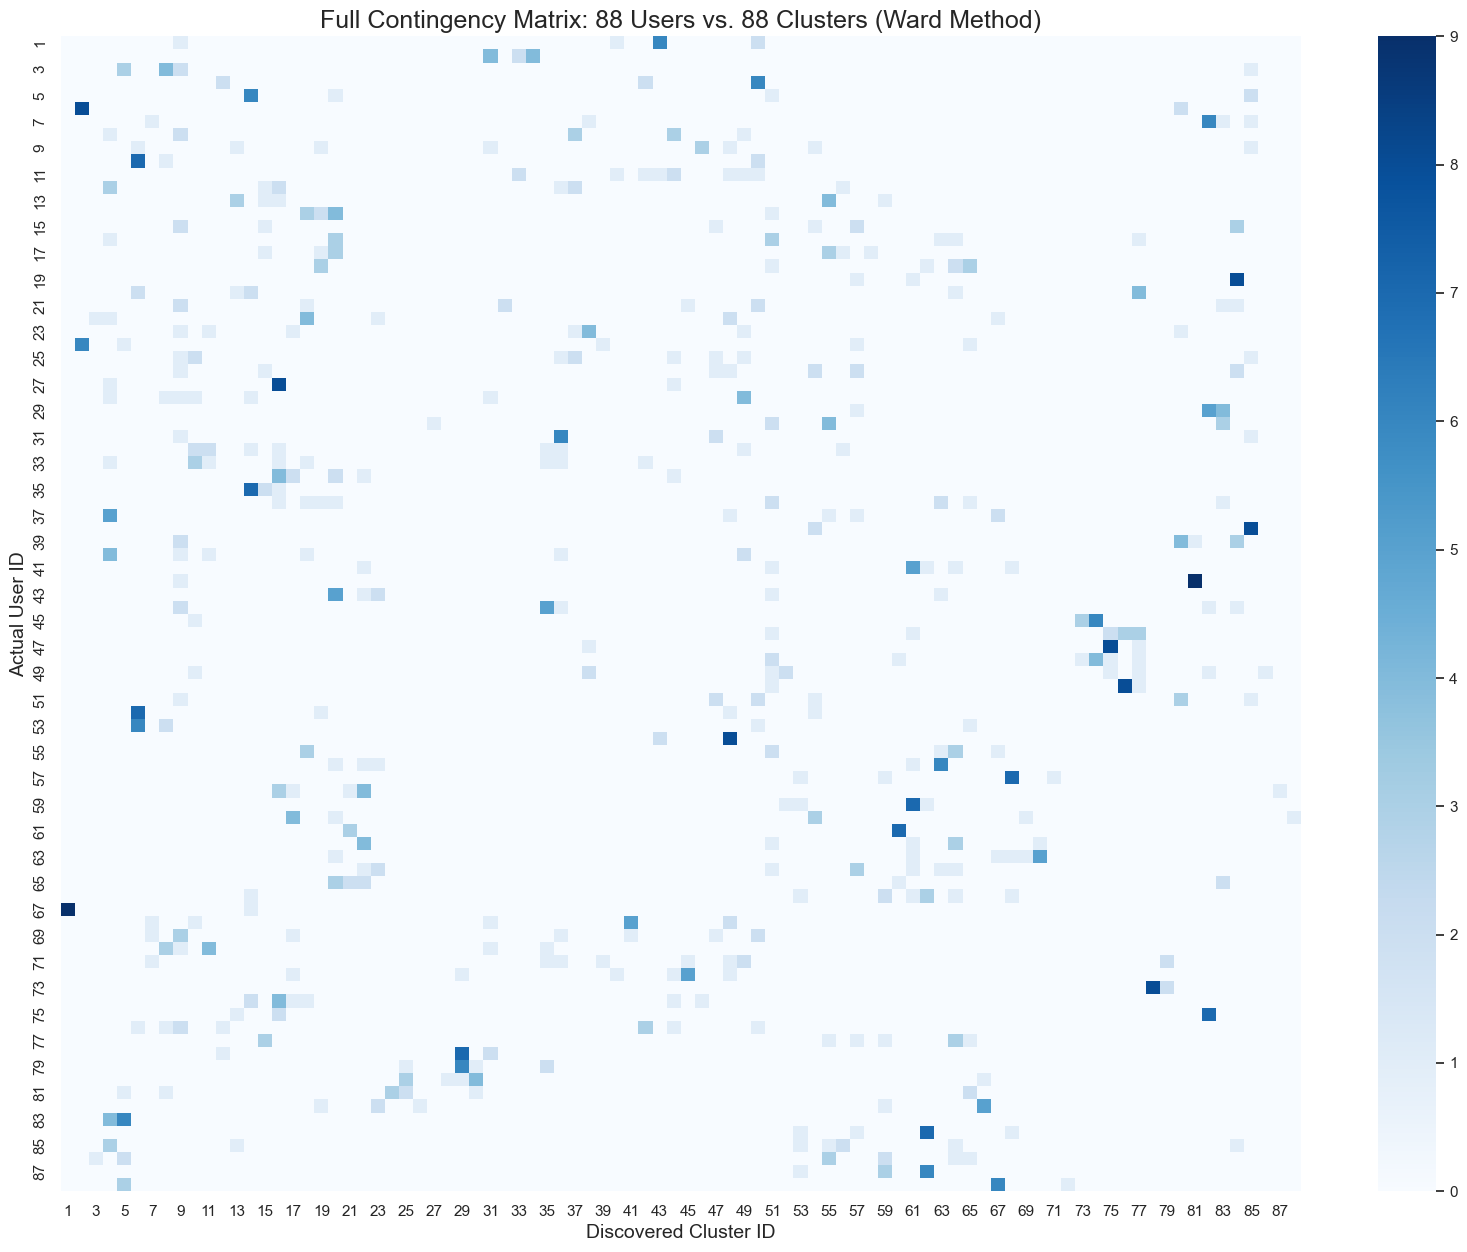


Summary of top 10 most 'Compact' Users (Sessions mostly in one cluster):


True_User
67    90.0
42    90.0
6     80.0
19    80.0
27    80.0
47    80.0
54    80.0
50    80.0
38    80.0
73    80.0
dtype: float64

In [10]:
# Re-run best model
best_Z = Z1 
best_clusters = clusters1

# Create Analysis DataFrame
analysis_df = pd.DataFrame({
    'True_User': y_true,
    'Cluster_ID': best_clusters
})

# 1. Calculate Cluster Purity
def calculate_purity(df):
    # For each cluster, find the most frequent user
    correct_assignments = 0
    for cluster in df['Cluster_ID'].unique():
        cluster_users = df[df['Cluster_ID'] == cluster]['True_User']
        if len(cluster_users) > 0:
            # Find the mode (most common user in this cluster)
            correct_assignments += cluster_users.value_counts().iloc[0]
    return correct_assignments / len(df)

purity = calculate_purity(analysis_df)

print(f"Overall Cluster Purity: {purity:.4f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(y_true, best_clusters):.4f}")

# 2. Identify 'Confused' Users
# A user is 'confused' if their 10 sessions are split into more than 1 cluster
user_cluster_counts = analysis_df.groupby('True_User')['Cluster_ID'].nunique()
confused_users = user_cluster_counts[user_cluster_counts > 1]
perfect_users = user_cluster_counts[user_cluster_counts == 1]

print(f"\nUsers perfectly clustered (All 10 sessions in 1 cluster): {len(perfect_users)}")
print(f"Users split across clusters: {len(confused_users)}")

# 3. Full Contingency Heatmap
plt.figure(figsize=(20, 15))
full_contingency = pd.crosstab(analysis_df['True_User'], analysis_df['Cluster_ID'])
sns.heatmap(full_contingency, cmap="Blues", cbar=True)
plt.title('Full Contingency Matrix: 88 Users vs. 88 Clusters (Ward Method)', fontsize=18)
plt.xlabel('Discovered Cluster ID', fontsize=14)
plt.ylabel('Actual User ID', fontsize=14)
plt.show()

# 4. Summary Table of Clustering Success
print("\nSummary of top 10 most 'Compact' Users (Sessions mostly in one cluster):")
cluster_distribution = pd.crosstab(analysis_df['True_User'], analysis_df['Cluster_ID'])
max_per_user = cluster_distribution.max(axis=1)
purity_per_user = (max_per_user / 10) * 100
display(purity_per_user.sort_values(ascending=False).head(10))